# Random Forest para Trading

Entrena un modelo de clasificación binaria sobre datos OHLCV de Freqtrade.

Pregunta objetivo: *¿sube el precio al menos X% en las próximas N velas?*
Si la probabilidad predicha supera el umbral → señal de compra.


---
## Configuración

Ajusta par, timeframe y parámetros del modelo aquí.


In [13]:
RUTA_DATOS = "../freqtrade/user_data/data/binance/"

PAR = "ETH/USDT" # BTC/USDT, ETH/USDT, SOL/USDT, BNB/USDT, XRP/USDT ...
TIMEFRAME = "15m"# 1m, 5m, 15m, 1h, 4h, 1d

OBJETIVO_PCT = 0.1 # % mínimo de subida para considerar la compra exitosa
HORIZONTE_VELAS = 30 # cuántas velas hacia adelante medimos el retorno

VELAS_ENTRENAMIENTO = 5000 # 5000 velas de 5m ≈ 17 días
VELAS_PRUEBA = 2000

UMBRAL_COMPRA= 0.55 # probabilidad mínima para generar señal de compra

N_ARBOLES= 200
PROFUNDIDAD_MAX = 6 # limita el crecimiento para reducir overfitting
SEMILLA = 42

print(f"Par: {PAR} | Timeframe: {TIMEFRAME}")
print(f"Objetivo: subir {OBJETIVO_PCT}% en {HORIZONTE_VELAS} velas")
print(f"Walk-forward: train={VELAS_ENTRENAMIENTO} velas, prueba={VELAS_PRUEBA} velas")


Par: ETH/USDT | Timeframe: 15m
Objetivo: subir 0.1% en 30 velas
Walk-forward: train=5000 velas, prueba=2000 velas


---
## Librerías y carga de datos


In [6]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import joblib

# Indicadores técnicos
try:
    import talib
    TIENE_TALIB = True
except ImportError:
    TIENE_TALIB = False
    print("TA-Lib no encontrado. Usando pandas para calcular indicadores.")

# Visualización
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('husl')


# FUNCIÓN: Construir ruta del archivo .feather
# Freqtrade guarda los datos con un formato específico de nombre
def construir_ruta(ruta_base, par, timeframe):
    """
    Construye la ruta al archivo .feather de Freqtrade.
    Ejemplo: BTC/USDT + 5m → BTC_USDT-5m.feather
    """
    nombre_par = par.replace("/", "_")  # BTC/USDT → BTC_USDT
    nombre_archivo = f"{nombre_par}-{timeframe}.feather"
    return os.path.join(ruta_base, nombre_archivo)


# FUNCIÓN: Cargar datos desde .feather
def cargar_datos(ruta_base, par, timeframe):
    """
    Carga el archivo .feather y lo convierte a un DataFrame limpio.
    Las columnas son: date, open, high, low, close, volume
    """
    ruta = construir_ruta(ruta_base, par, timeframe)
    
    if not os.path.exists(ruta):
        print(f"Archivo no encontrado: {ruta}")
        print(f"Descárgalo con: docker compose run --rm freqtrade download-data --pairs {par} --timeframes {timeframe} --timerange 20250101-20260430")
        return None
    
    df = pd.read_feather(ruta)
    
    # Freqtrade guarda la fecha en milisegundos (unix timestamp)
    if 'date' not in df.columns and df.columns[0] != 'date':
        df.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
    
    # Convertir timestamp a fecha legible
    if df['date'].dtype in ['int64', 'float64']:
        df['date'] = pd.to_datetime(df['date'], unit='ms', utc=True)
    else:
        df['date'] = pd.to_datetime(df['date'], utc=True)
    
    df = df.sort_values('date').reset_index(drop=True)
    
    print(f"Datos cargados: {par} {timeframe}")
    print(f"   Total de velas: {len(df):,}")
    print(f"   Desde: {df['date'].iloc[0].strftime('%Y-%m-%d %H:%M')}")
    print(f"   Hasta: {df['date'].iloc[-1].strftime('%Y-%m-%d %H:%M')}")
    print(f"   Precio actual (última vela): ${df['close'].iloc[-1]:,.2f}")
    
    return df


# --- Cargar datos ---
df_raw = cargar_datos(RUTA_DATOS, PAR, TIMEFRAME)

if df_raw is not None:
    df_raw.head(3)

Datos cargados: ETH/USDT 15m
   Total de velas: 46,998
   Desde: 2025-01-01 00:00
   Hasta: 2026-05-05 13:15
   Precio actual (última vela): $2,390.00


---
## Features

Indicadores técnicos calculados sobre datos pasados únicamente.
Cuando se integre TDA, los features de entropía topológica van al final de `calcular_features` (ver placeholder).


In [7]:
def calcular_features(df):
    """
    Calcula indicadores técnicos para todas las velas.
    Solo usa datos del pasado — sin lookahead.
    """
    d = df.copy()
    
    close  = d['close'].values.astype(float)
    high   = d['high'].values.astype(float)
    low    = d['low'].values.astype(float)
    volume = d['volume'].values.astype(float)
    open_  = d['open'].values.astype(float)
    
    d['ret_1']  = pd.Series(close).pct_change(1).values * 100
    d['ret_3']  = pd.Series(close).pct_change(3).values * 100
    d['ret_6']  = pd.Series(close).pct_change(6).values * 100
    d['ret_12'] = pd.Series(close).pct_change(12).values * 100
    d['ret_24'] = pd.Series(close).pct_change(24).values * 100

    d['cuerpo_vela'] = (close - open_) / (open_ + 1e-9) * 100
    
    d['rango_vela'] = (high - low) / (low + 1e-9) * 100

    for periodo in [7, 14, 21, 50, 100, 200]:
        ema = pd.Series(close).ewm(span=periodo, adjust=False).mean().values
        d[f'dist_ema_{periodo}'] = (close - ema) / (ema + 1e-9) * 100

    ema_7  = pd.Series(close).ewm(span=7,  adjust=False).mean().values
    ema_21 = pd.Series(close).ewm(span=21, adjust=False).mean().values
    ema_50 = pd.Series(close).ewm(span=50, adjust=False).mean().values
    
    d['cruce_ema_7_21']  = (ema_7  - ema_21) / (ema_21 + 1e-9) * 100
    d['cruce_ema_7_50']  = (ema_7  - ema_50) / (ema_50 + 1e-9) * 100
    d['cruce_ema_21_50'] = (ema_21 - ema_50) / (ema_50 + 1e-9) * 100

    # ¿Está el mercado sobrecomprado (>70) o sobrevendido (<30)?
    def calcular_rsi(precios, periodo=14):
        """Calcula el RSI sin TA-Lib"""
        delta = pd.Series(precios).diff()
        ganancia = delta.clip(lower=0)
        perdida  = -delta.clip(upper=0)
        avg_ganancia = ganancia.ewm(com=periodo - 1, adjust=False).mean()
        avg_perdida  = perdida.ewm(com=periodo - 1, adjust=False).mean()
        rs = avg_ganancia / (avg_perdida + 1e-9)
        return (100 - (100 / (1 + rs))).values

    if TIENE_TALIB:
        d['rsi_14'] = talib.RSI(close, timeperiod=14)
        d['rsi_7']  = talib.RSI(close, timeperiod=7)
    else:
        d['rsi_14'] = calcular_rsi(close, 14)
        d['rsi_7']  = calcular_rsi(close, 7)

    d['rsi_14_norm'] = (d['rsi_14'] - 50) / 50
    d['rsi_7_norm']  = (d['rsi_7']  - 50) / 50

    # ¿Qué tan agitado está el mercado?
    retornos = pd.Series(close).pct_change()
    d['volatilidad_6']  = retornos.rolling(6).std().values  * 100
    d['volatilidad_14'] = retornos.rolling(14).std().values * 100
    d['volatilidad_24'] = retornos.rolling(24).std().values * 100

    # ¿Hay más o menos actividad de lo normal?
    vol_series = pd.Series(volume)
    vol_ma14 = vol_series.rolling(14).mean()
    d['ratio_volumen_14'] = (volume / (vol_ma14.values + 1e-9))
    d['vol_ret_1'] = vol_series.pct_change(1).values

    # ¿Está el precio en la zona alta, media o baja de su rango reciente?
    precio_series = pd.Series(close)
    bb_media = precio_series.rolling(20).mean()
    bb_std   = precio_series.rolling(20).std()
    bb_upper = (bb_media + 2 * bb_std).values
    bb_lower = (bb_media - 2 * bb_std).values
    bb_width = bb_upper - bb_lower
    
    d['bb_posicion'] = (close - bb_lower) / (bb_width + 1e-9)
    d['bb_ancho_norm'] = bb_width / (bb_media.values + 1e-9)

    # ¿El momentum está acelerando o desacelerando?
    ema_12 = precio_series.ewm(span=12, adjust=False).mean().values
    ema_26 = precio_series.ewm(span=26, adjust=False).mean().values
    macd_line   = ema_12 - ema_26
    signal_line = pd.Series(macd_line).ewm(span=9, adjust=False).mean().values
    
    d['macd_diff'] = macd_line - signal_line
    d['macd_norm'] = macd_line / (close + 1e-9) * 100

    # d['tda_entropia_h0'] = ...
    # d['tda_entropia_h1'] = ...
    # d['tda_suma_h1'] = ...
    return d


if df_raw is not None:
    df_features = calcular_features(df_raw)
    
    COLUMNAS_FEATURES = [
        'ret_1', 'ret_3', 'ret_6', 'ret_12', 'ret_24',
        'cuerpo_vela', 'rango_vela',
        'dist_ema_7', 'dist_ema_14', 'dist_ema_21', 'dist_ema_50', 'dist_ema_100', 'dist_ema_200',
        'cruce_ema_7_21', 'cruce_ema_7_50', 'cruce_ema_21_50',
        'rsi_14_norm', 'rsi_7_norm',
        'volatilidad_6', 'volatilidad_14', 'volatilidad_24',
        'ratio_volumen_14', 'vol_ret_1',
        'bb_posicion', 'bb_ancho_norm',
        'macd_diff', 'macd_norm',
    ]
    
    print(f"{len(COLUMNAS_FEATURES)} features calculados")
    df_features[COLUMNAS_FEATURES].tail(3)

27 features calculados


---
## Target

Etiqueta binaria por vela: 1 si el precio subió al menos `OBJETIVO_PCT`% en `HORIZONTE_VELAS` velas, 0 si no.
Las últimas N velas se descartan por no tener futuro disponible.


Target construido:
Total de velas con target: 46,968
Velas donde SÍ subió 0.1% en 30 velas: 22,451 (47.8%)
Velas donde NO subió: 24,517 (52.2%)

Balance buenillo. El modelo tiene suficiente pa aprender.


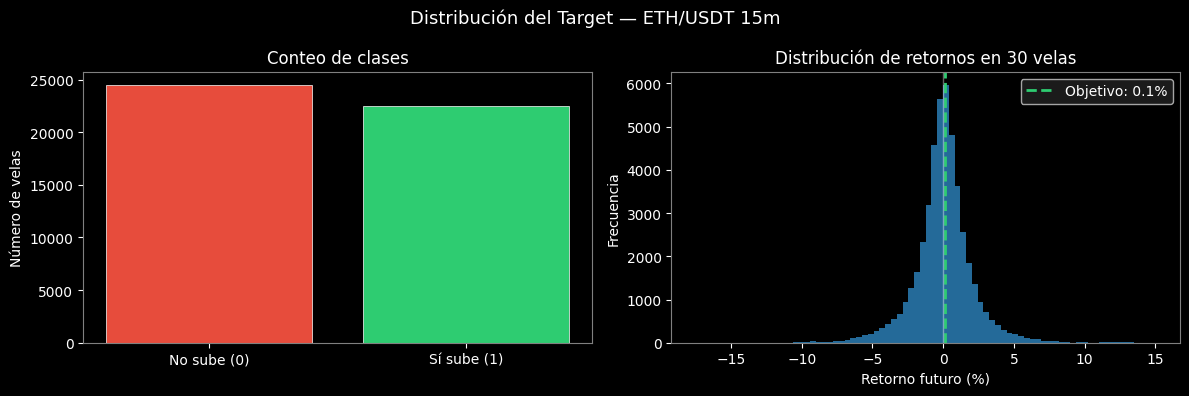

In [14]:
def construir_target(df, objetivo_pct, horizonte_velas):
    """
    Crea la columna 'target' que dice si fue buena idea comprar en cada vela.
    
    Lógica:
        retorno_futuro = (precio_futuro - precio_ahora) / precio_ahora * 100
        target = 1 si retorno_futuro >= objetivo_pct
        target = 0 si no
    """
    d = df.copy()
    
    # Precio N velas hacia adelante
    # shift(-N) mueve la columna N filas "hacia arriba" (hacia el futuro)
    precio_futuro = d['close'].shift(-horizonte_velas)
    
    # Retorno porcentual
    retorno_futuro = (precio_futuro - d['close']) / d['close'] * 100
    
    # Target binario
    d['target'] = (retorno_futuro >= objetivo_pct).astype(int)
    d['retorno_futuro_pct'] = retorno_futuro  # guardamos para análisis
    
    # Las últimas N velas no tienen futuro → las eliminamos
    d = d.iloc[:-horizonte_velas].copy()
    
    return d


if df_raw is not None:
    df_con_target = construir_target(df_features, OBJETIVO_PCT, HORIZONTE_VELAS)
    
    total = len(df_con_target)
    positivos = df_con_target['target'].sum()
    negativos = total - positivos
    
    print(f"Target construido:")
    print(f"Total de velas con target: {total:,}")
    print(f"Velas donde SÍ subió {OBJETIVO_PCT}% en {HORIZONTE_VELAS} velas: {positivos:,} ({positivos/total*100:.1f}%)")
    print(f"Velas donde NO subió: {negativos:,} ({negativos/total*100:.1f}%)")
    
    if positivos/total < 0.25:
        print(f"\nPocas muestras positivas. O bajar OBJETIVO_PCT o subir HORIZONTE_VELAS.")
    elif positivos/total > 0.75:
        print(f"\nDemasiadas muestras positivas. O subir OBJETIVO_PCT o bajar HORIZONTE_VELAS.")
    else:
        print(f"\nBalance buenillo. El modelo tiene suficiente pa aprender.")

    # Visualización de la distribución del target
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Distribución del Target — {PAR} {TIMEFRAME}', color='white', fontsize=13)

    # Gráfica 1: conteo de 0s y 1s
    conteos = df_con_target['target'].value_counts()
    axes[0].bar(['No sube (0)', 'Sí sube (1)'], conteos.values,
                color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=0.5)
    axes[0].set_title('Conteo de clases', color='white')
    axes[0].set_ylabel('Número de velas', color='white')
    axes[0].tick_params(colors='white')
    for spine in axes[0].spines.values():
        spine.set_edgecolor('gray')

    # Gráfica 2: distribución del retorno futuro
    axes[1].hist(df_con_target['retorno_futuro_pct'].dropna(), bins=80,
                 color='#3498db', alpha=0.7, edgecolor='none')
    axes[1].axvline(OBJETIVO_PCT, color='#2ecc71', linestyle='--',
                    linewidth=2, label=f'Objetivo: {OBJETIVO_PCT}%')
    axes[1].axvline(0, color='white', linestyle='-', linewidth=1, alpha=0.4)
    axes[1].set_title(f'Distribución de retornos en {HORIZONTE_VELAS} velas', color='white')
    axes[1].set_xlabel('Retorno futuro (%)', color='white')
    axes[1].set_ylabel('Frecuencia', color='white')
    axes[1].tick_params(colors='white')
    axes[1].legend(facecolor='#222', labelcolor='white')
    for spine in axes[1].spines.values():
        spine.set_edgecolor('gray')

    plt.tight_layout()
    plt.show()

---
## Entrenamiento walk-forward

El modelo siempre predice sobre datos que no vio durante el entrenamiento.

```
Bloque 1: [train 1]            → [prueba 1]
Bloque 2: [train 1 + prueba 1] → [prueba 2]
...
```


In [9]:
def walk_forward_rf(df, columnas_features, velas_entrenamiento, velas_prueba,
                    n_arboles, profundidad_max, semilla, umbral_compra):
    """
    Entrenamiento Walk-Forward con Random Forest.
    
    Retorna un DataFrame con las predicciones en cada bloque de prueba,
    y una lista con los modelos entrenados en cada bloque.
    """
    
    df_limpio = df[columnas_features + ['target', 'date', 'close', 'retorno_futuro_pct']].dropna().copy()
    df_limpio = df_limpio.reset_index(drop=True)
    
    n_total = len(df_limpio)
    print(f"Datos tras limpiar NaN: {n_total:,} velas")
    
    if n_total < velas_entrenamiento + velas_prueba:
        print(f"Sin suficientes datos (mínimo {velas_entrenamiento + velas_prueba:,} velas).")
        return None, None
    
    resultados = []
    modelos    = []
    importancias = []
    
    inicio_prueba = velas_entrenamiento
    num_bloques   = 0

    while inicio_prueba + velas_prueba <= n_total:
        
        train = df_limpio.iloc[:inicio_prueba]
        test  = df_limpio.iloc[inicio_prueba : inicio_prueba + velas_prueba]
        
        X_train = train[columnas_features].values
        y_train = train['target'].values
        
        X_test  = test[columnas_features].values
        y_test  = test['target'].values
        
        modelo = RandomForestClassifier(
            n_estimators=n_arboles,
            max_depth=profundidad_max,
            random_state=semilla,
            n_jobs=-1,
            class_weight='balanced',
            min_samples_leaf=20,
        )
        modelo.fit(X_train, y_train)
        
        # predict_proba[:, 1] = probabilidad de subida
        proba_sube = modelo.predict_proba(X_test)[:, 1]
        prediccion = (proba_sube >= umbral_compra).astype(int)
        
        bloque_resultados = test[['date', 'close', 'target', 'retorno_futuro_pct']].copy()
        bloque_resultados['prediccion']  = prediccion
        bloque_resultados['prob_sube']   = proba_sube
        bloque_resultados['num_bloque']  = num_bloques
        bloque_resultados['n_train']     = len(train)
        
        resultados.append(bloque_resultados)
        modelos.append(modelo)
        importancias.append(modelo.feature_importances_)
        
        acc   = accuracy_score(y_test, prediccion)
        prec  = precision_score(y_test, prediccion, zero_division=0)
        señales = prediccion.sum()
        
        print(f"  Bloque {num_bloques+1:2d}: "
              f"train={len(train):,} velas | "
              f"prueba={len(test):,} velas | "
              f"accuracy={acc:.3f} | "
              f"precision={prec:.3f} | "
              f"señales de compra={señales}")

        inicio_prueba += velas_prueba
        num_bloques   += 1

    if not resultados:
        print("❌ No se generaron bloques.")
        return None, None

    df_resultados = pd.concat(resultados, ignore_index=True)
    importancia_promedio = np.mean(importancias, axis=0)
    
    print(f"Walk-forward: {num_bloques} bloques")
    print(f"Predicciones totales: {len(df_resultados):,} velas")
    
    return df_resultados, modelos, importancia_promedio


# --- Ejecutar ---
if df_raw is not None:
    print(f"Walk-forward: {PAR} {TIMEFRAME}")
    
    resultados_wf, modelos_wf, importancia_wf = walk_forward_rf(
        df        = df_con_target,
        columnas_features = COLUMNAS_FEATURES,
        velas_entrenamiento = VELAS_ENTRENAMIENTO,
        velas_prueba = VELAS_PRUEBA,
        n_arboles   = N_ARBOLES,
        profundidad_max = PROFUNDIDAD_MAX,
        semilla     = SEMILLA,
        umbral_compra = UMBRAL_COMPRA,
    )

Walk-forward: ETH/USDT 15m
Datos tras limpiar NaN: 46,944 velas
  Bloque  1: train=5,000 velas | prueba=2,000 velas | accuracy=0.548 | precision=0.507 | señales de compra=952
  Bloque  2: train=7,000 velas | prueba=2,000 velas | accuracy=0.543 | precision=0.485 | señales de compra=485
  Bloque  3: train=9,000 velas | prueba=2,000 velas | accuracy=0.544 | precision=0.580 | señales de compra=533
  Bloque  4: train=11,000 velas | prueba=2,000 velas | accuracy=0.528 | precision=0.631 | señales de compra=222
  Bloque  5: train=13,000 velas | prueba=2,000 velas | accuracy=0.546 | precision=0.527 | señales de compra=510
  Bloque  6: train=15,000 velas | prueba=2,000 velas | accuracy=0.505 | precision=0.536 | señales de compra=487
  Bloque  7: train=17,000 velas | prueba=2,000 velas | accuracy=0.432 | precision=0.578 | señales de compra=185
  Bloque  8: train=19,000 velas | prueba=2,000 velas | accuracy=0.487 | precision=0.567 | señales de compra=261
  Bloque  9: train=21,000 velas | prueba=2,

---
## Evaluación


  RESULTADOS: ETH/USDT 15m
  Total de velas evaluadas:   40,000
  Señales de compra emitidas: 6,994 (17.5% de las velas)

  — CLASIFICACIÓN —
  Accuracy:  0.525  (¿qué % de predicciones son correctas?)
  Precision: 0.510  (cuando dice 'compra', ¿qué % son correctas?)
  Recall:    0.186  (¿qué % de las buenas oportunidades detecta?)

  — RENTABILIDAD ESTIMADA (en señales de compra) —
  Win Rate de señales (sube en 30 velas): 51.0%
  Retorno promedio por señal: +0.090%
  Retorno mediana por señal:  +0.126%
  Retorno promedio sin filtrar (todo el mercado): +0.011%
  Mejora del modelo vs mercado aleatorio: +0.080%
  El modelo selecciona velas con mejor retorno que el promedio


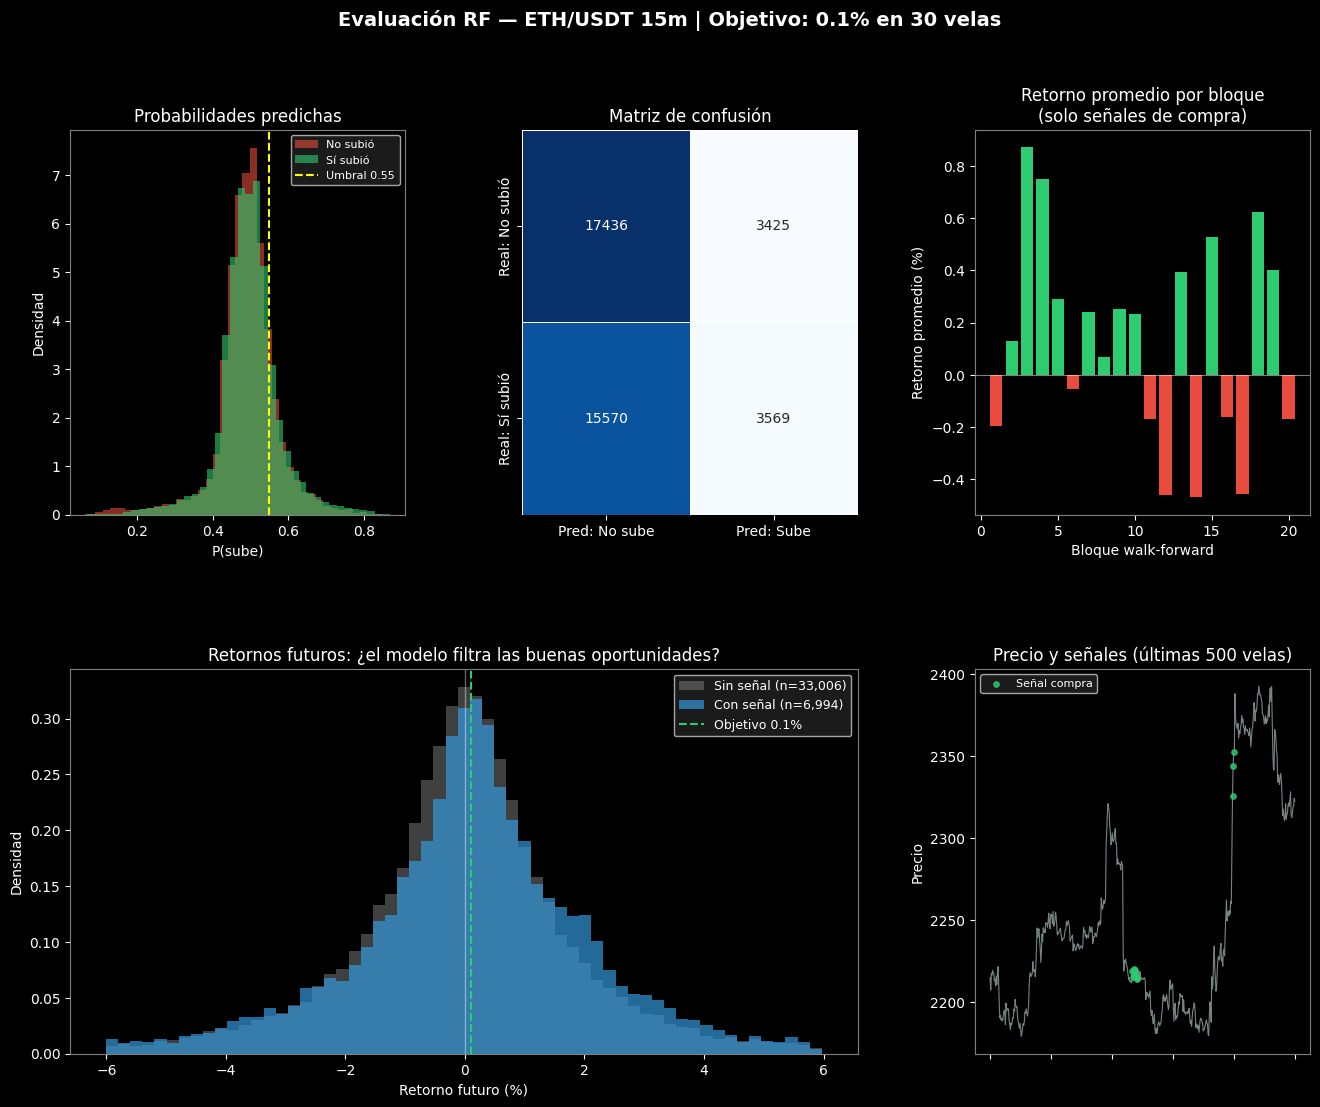

In [10]:
def evaluar_resultados(df_resultados, objetivo_pct, horizonte_velas, par, timeframe, umbral_compra):
    """
    Calcula métricas de desempeño del modelo y muestra gráficas.
    """
    if df_resultados is None or len(df_resultados) == 0:
        print("Sin resultados para evaluar.")
        return {}

    y_true = df_resultados['target'].values
    y_pred = df_resultados['prediccion'].values

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    # Esto NO es un backtesting completo — es solo una estimación.
    señales = df_resultados[df_resultados['prediccion'] == 1].copy()
    n_señales = len(señales)
    
    if n_señales > 0:
        retorno_promedio_señal  = señales['retorno_futuro_pct'].mean()
        retorno_mediana_señal   = señales['retorno_futuro_pct'].median()
        win_rate_señal = (señales['retorno_futuro_pct'] > 0).mean() * 100
        win_rate_target = señales['target'].mean() * 100
    else:
        retorno_promedio_señal = retorno_mediana_señal = win_rate_señal = win_rate_target = 0

    retorno_promedio_total = df_resultados['retorno_futuro_pct'].mean()

    print("="*60)
    print(f"  RESULTADOS: {par} {timeframe}")
    print("="*60)
    print(f"  Total de velas evaluadas:   {len(df_resultados):,}")
    print(f"  Señales de compra emitidas: {n_señales:,} ({n_señales/len(df_resultados)*100:.1f}% de las velas)")
    print()
    print(f"  — CLASIFICACIÓN —")
    print(f"  Accuracy:  {acc:.3f}  (¿qué % de predicciones son correctas?)")
    print(f"  Precision: {prec:.3f}  (cuando dice 'compra', ¿qué % son correctas?)")
    print(f"  Recall:    {rec:.3f}  (¿qué % de las buenas oportunidades detecta?)")
    print()
    print(f"  — RENTABILIDAD ESTIMADA (en señales de compra) —")
    print(f"  Win Rate de señales (sube en {horizonte_velas} velas): {win_rate_target:.1f}%")
    print(f"  Retorno promedio por señal: {retorno_promedio_señal:+.3f}%")
    print(f"  Retorno mediana por señal:  {retorno_mediana_señal:+.3f}%")
    print(f"  Retorno promedio sin filtrar (todo el mercado): {retorno_promedio_total:+.3f}%")
    
    mejora = retorno_promedio_señal - retorno_promedio_total
    print(f"  Mejora del modelo vs mercado aleatorio: {mejora:+.3f}%")
    
    if mejora > 0:
        print(f"  El modelo selecciona velas con mejor retorno que el promedio")
    else:
        print(f"  El modelo no mejora sobre elegir velas al azar")
    print("="*60)

    # GRÁFICAS
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f'Evaluación RF — {par} {timeframe} | Objetivo: {objetivo_pct}% en {horizonte_velas} velas',
                 color='white', fontsize=14, fontweight='bold')
    gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    for clase, color, label in [(0, '#e74c3c', 'No subió'), (1, '#2ecc71', 'Sí subió')]:
        mask = df_resultados['target'] == clase
        ax1.hist(df_resultados.loc[mask, 'prob_sube'], bins=40,
                 alpha=0.6, color=color, label=label, density=True)
    ax1.axvline(umbral_compra, color='yellow', linestyle='--', linewidth=1.5, label=f'Umbral {umbral_compra}')
    ax1.set_title('Probabilidades predichas', color='white')
    ax1.set_xlabel('P(sube)', color='white'); ax1.set_ylabel('Densidad', color='white')
    ax1.tick_params(colors='white'); ax1.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax1.spines.values(): sp.set_edgecolor('gray')

    ax2 = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=['Pred: No sube', 'Pred: Sube'],
                yticklabels=['Real: No subió', 'Real: Sí subió'],
                cbar=False, linewidths=0.5)
    ax2.set_title('Matriz de confusión', color='white')
    ax2.tick_params(colors='white')
    for sp in ax2.spines.values(): sp.set_edgecolor('gray')

    ax3 = fig.add_subplot(gs[0, 2])
    retornos_por_bloque = df_resultados[df_resultados['prediccion'] == 1].groupby('num_bloque')['retorno_futuro_pct'].mean()
    colores_barras = ['#2ecc71' if r > 0 else '#e74c3c' for r in retornos_por_bloque.values]
    ax3.bar(retornos_por_bloque.index + 1, retornos_por_bloque.values, color=colores_barras)
    ax3.axhline(0, color='white', linewidth=0.8, alpha=0.5)
    ax3.set_title('Retorno promedio por bloque\n(solo señales de compra)', color='white')
    ax3.set_xlabel('Bloque walk-forward', color='white')
    ax3.set_ylabel('Retorno promedio (%)', color='white')
    ax3.tick_params(colors='white')
    for sp in ax3.spines.values(): sp.set_edgecolor('gray')

    ax4 = fig.add_subplot(gs[1, 0:2])
    no_señal = df_resultados[df_resultados['prediccion'] == 0]['retorno_futuro_pct']
    sí_señal = df_resultados[df_resultados['prediccion'] == 1]['retorno_futuro_pct']
    bins = np.linspace(df_resultados['retorno_futuro_pct'].quantile(0.01),
                       df_resultados['retorno_futuro_pct'].quantile(0.99), 60)
    ax4.hist(no_señal, bins=bins, alpha=0.5, color='gray',    density=True, label=f'Sin señal (n={len(no_señal):,})')
    ax4.hist(sí_señal, bins=bins, alpha=0.7, color='#3498db', density=True, label=f'Con señal (n={len(sí_señal):,})')
    ax4.axvline(0, color='white', linestyle='-', linewidth=1, alpha=0.4)
    ax4.axvline(objetivo_pct, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Objetivo {objetivo_pct}%')
    ax4.set_title('Retornos futuros: ¿el modelo filtra las buenas oportunidades?', color='white')
    ax4.set_xlabel('Retorno futuro (%)', color='white'); ax4.set_ylabel('Densidad', color='white')
    ax4.tick_params(colors='white')
    ax4.legend(facecolor='#222', labelcolor='white', fontsize=9)
    for sp in ax4.spines.values(): sp.set_edgecolor('gray')

    ax5 = fig.add_subplot(gs[1, 2])
    ultimos = df_resultados.tail(500).copy()
    señales_plot = ultimos[ultimos['prediccion'] == 1]
    ax5.plot(ultimos.index, ultimos['close'], color='#95a5a6', linewidth=0.8, alpha=0.8)
    ax5.scatter(señales_plot.index, señales_plot['close'],
                color='#2ecc71', s=15, zorder=5, alpha=0.8, label='Señal compra')
    ax5.set_title('Precio y señales (últimas 500 velas)', color='white')
    ax5.set_ylabel('Precio', color='white')
    ax5.tick_params(colors='white', labelbottom=False)
    ax5.legend(facecolor='#222', labelcolor='white', fontsize=8)
    for sp in ax5.spines.values(): sp.set_edgecolor('gray')

    plt.show()

    return {
        'par': par, 'timeframe': timeframe,
        'objetivo_pct': objetivo_pct, 'horizonte_velas': horizonte_velas,
        'n_señales': n_señales, 'n_total': len(df_resultados),
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'win_rate_target': win_rate_target,
        'retorno_promedio_señal': retorno_promedio_señal,
        'retorno_promedio_mercado': retorno_promedio_total,
        'mejora_vs_mercado': mejora,
    }


if resultados_wf is not None:
    metricas = evaluar_resultados(
        resultados_wf, OBJETIVO_PCT, HORIZONTE_VELAS,
        PAR, TIMEFRAME, UMBRAL_COMPRA
    )

---
## Guardar el modelo

Guarda el `.pkl` y un JSON de configuración. `RFStrategy.py` carga este archivo al arrancar.


In [11]:
import os
from datetime import datetime

def guardar_modelo(modelo, columnas_features, par, timeframe, objetivo_pct,
                   horizonte_velas, umbral_compra, metricas, carpeta="modelos_rf"):
    """
    Guarda el modelo entrenado y su configuración.
    La estrategia de Freqtrade cargará este archivo.
    """
    os.makedirs(carpeta, exist_ok=True)
    
    nombre_par = par.replace('/', '_')
    timestamp  = datetime.now().strftime("%Y%m%d_%H%M")
    nombre     = f"rf_{nombre_par}_{timeframe}_{timestamp}"
    
    ruta_modelo = os.path.join(carpeta, f"{nombre}.pkl")
    joblib.dump(modelo, ruta_modelo)
    
    config = {
        'par': par,
        'timeframe': timeframe,
        'objetivo_pct': objetivo_pct,
        'horizonte_velas': horizonte_velas,
        'umbral_compra': umbral_compra,
        'columnas_features': columnas_features,
        'fecha_entrenamiento': timestamp,
        'metricas': metricas,
    }
    ruta_config = os.path.join(carpeta, f"{nombre}_config.json")
    import json
    with open(ruta_config, 'w') as f:
        json.dump(config, f, indent=2, default=str)

    print(f"Modelo: {ruta_modelo}")
    print(f"Config: {ruta_config}")
    
    return ruta_modelo


if modelos_wf and metricas:
    modelo_final = modelos_wf[-1]
    ruta_guardada = guardar_modelo(
        modelo_final, COLUMNAS_FEATURES, PAR, TIMEFRAME,
        OBJETIVO_PCT, HORIZONTE_VELAS, UMBRAL_COMPRA, metricas
    )

Modelo: modelos_rf/rf_ETH_USDT_15m_20260516_1242.pkl
Config: modelos_rf/rf_ETH_USDT_15m_20260516_1242_config.json
